<a href="https://colab.research.google.com/github/lucasFavieri/economic-data-analysis-hypothesis-testing/blob/main/hypothesis_testing_qog_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# ============================================================================
# MINI-HACKATHON: HYPOTHESIS TESTING ON REAL ECONOMIC DATA
# ============================================================================
#
# Student Name: Lucas Favieri
#
#
# OBJECTIVE:
# You will analyze real economic data from the Quality of Government (QoG) Institute,
# propose a hypothesis based on economic theory, test it using inferential statistics,
# and present your findings in a 5-minute presentation (upload to the Facultet platform).
#
# DELIVERABLES:
# 1. One testable hypothesis grounded in socio-economic theory
# 2. Statistical test results using one of four approved tests
# 3. Publication-quality visualization showing the relationship
# 4. 5-minute presentation of your work
#
# APPROVED STATISTICAL TESTS:
# 1. Independent t-test (comparing means between two groups)
# 2. Pearson correlation (relationship between two continuous variables)
# 3. Chi-square test (independence between categorical variables)
# 4. One-way ANOVA (comparing means across 3+ groups)
#
# TIME ALLOCATION (2.5 hours):
# - Phase 1: Data Exploration (30 min)
# - Phase 2: Theory & Hypothesis Development (30 min)
# - Phase 3: Statistical Testing & Visualization (45 min)
# - Phase 4: Presentation Preparation (45 min)
#
# DATA SOURCE: Quality of Government (QoG) Standard Dataset
# - Combines data from 100+ sources including World Bank, Polity, Freedom House, V-Dem
# - Cross-sectional data for year 2020
# - Variables cover governance, economics, development, and political systems
#
# NOTE: We use cross-sectional data (one year) to ensure observations are independent,
# which is required for the statistical tests we're using today.

# ============================================================================
# SETUP: Import Libraries
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, pearsonr, chi2_contingency, f_oneway
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

# Set style for publication-quality plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 11


# ============================================================================
# LOAD DATASET
# ============================================================================
# Place WDI_Data.csv in the same folder as this notebook

dataset_url= 'https://raw.githubusercontent.com/lucasFavieri/economic-data-analysis-hypothesis-testing/refs/heads/main/WDI_Data%20(1).csv'
df = pd.read_csv(dataset_url)


# ============================================================================
# EXPLORE THE DATA
# ============================================================================

# List all variable names
print(list(df.columns))

# Dataset shape (rows, columns)
print(df.shape)

# Basic descriptive statistics
df.describe()


['cname', 'ccodealp', 'ccode', 'year', 'wbgi_cce', 'wbgi_gee', 'wbgi_pve', 'wbgi_rle', 'wbgi_rqe', 'wbgi_vae', 'vdem_corr', 'ti_cpi', 'icrg_qog', 'fh_status', 'fh_pr', 'fh_cl', 'p_polity2', 'vdem_polyarchy', 'wdi_trade', 'wdi_taxrev', 'pwt_pop', 'mad_gdppc', 'wdi_lifexp', 'wdi_pop', 'wdi_fertility', 'wdi_expedu', 'wdi_gini', 'wdi_empagr', 'wdi_internet', 'wdi_mobile', 'wdi_co2', 'wdi_forest', 'wdi_migration', 'vdem_libdem', 'vdem_partip', 'vdem_delibdem', 'vdem_egal', 'br_pvote', 'ucdp_type4']
(199, 39)


,ccode,year,wbgi_cce,wbgi_gee,wbgi_pve,wbgi_rle,wbgi_rqe,wbgi_vae,vdem_corr,ti_cpi,...,wdi_mobile,wdi_co2,wdi_forest,wdi_migration,vdem_libdem,vdem_partip,vdem_delibdem,vdem_egal,br_pvote,ucdp_type4
count,198.000000,199.0,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,178.000000,183.000000,...,198.000000,191.000000,198.000000,1.980000e+02,178.000000,178.000000,178.000000,178.000000,194.000000,103.000000
mean,431.515152,2020.0,-0.081915,-0.086988,-0.116604,-0.102683,-0.100718,-0.067929,0.495747,42.825137,...,104.888014,4.306350,32.215773,4.435884e+03,0.400556,0.489354,0.400573,0.598837,0.494845,3.106796
std,255.527954,0.0,1.018581,1.012013,1.022546,1.021210,1.006750,1.016049,0.306341,18.987330,...,34.725401,7.110715,24.105643,1.284137e+05,0.264736,0.184668,0.249639,0.221659,0.501267,2.235685
min,4.000000,2020.0,-1.936870,-2.362376,-2.711848,-2.331935,-2.370466,-2.155002,0.002000,12.000000,...,12.671801,0.000000,0.000000,-1.025295e+06,0.010000,0.027000,0.013000,0.050000,0.000000,0.000000
25%,205.000000,2020.0,-0.851131,-0.757555,-0.668346,-0.801619,-0.796627,-0.924483,0.197000,28.000000,...,81.949776,0.657221,11.346615,-1.005475e+04,0.152000,0.376500,0.200250,0.441250,0.000000,2.000000
50%,427.000000,2020.0,-0.193254,-0.158798,-0.065773,-0.231920,-0.130580,0.046246,0.542500,39.000000,...,107.548937,2.123163,31.371095,-4.365000e+02,0.391000,0.547500,0.367000,0.615500,0.000000,2.000000
75%,661.250000,2020.0,0.606134,0.541927,0.713827,0.596960,0.526448,0.839547,0.767250,56.000000,...,129.749177,5.027577,49.606197,7.650000e+03,0.637500,0.619000,0.601500,0.791250,1.000000,4.000000
max,894.000000,2020.0,2.236486,2.284203,1.669218,2.018592,2.205299,1.720227,0.962000,88.000000,...,198.566865,71.010461,97.412115,6.755600e+05,0.883000,0.873000,0.879000,0.972000,1.000000,11.000000


# ***Preparing DATA***

In [5]:
df_clean = df.dropna(subset=['wdi_internet', 'mad_gdppc', 'fh_status'])
df_clean

,cname,ccodealp,ccode,year,wbgi_cce,wbgi_gee,wbgi_pve,wbgi_rle,wbgi_rqe,wbgi_vae,...,wdi_mobile,wdi_co2,wdi_forest,wdi_migration,vdem_libdem,vdem_partip,vdem_delibdem,vdem_egal,br_pvote,ucdp_type4
0,Afghanistan,AFG,4.0,2020,-1.493361,-1.611539,-2.702721,-1.831407,-1.389163,-1.078267,...,58.190214,0.140323,1.852782,166821.0,0.191,0.265,0.291,0.429,0.0,3.0
1,Albania,ALB,8.0,2020,-0.573539,-0.155121,0.088613,-0.378028,0.221967,0.086325,...,91.350501,1.516219,28.791971,-9117.0,0.447,0.555,0.280,0.708,1.0,NaN
2,Algeria,DZA,12.0,2020,-0.666827,-0.573643,-0.847820,-0.798028,-1.355300,-1.088509,...,104.842178,3.857946,0.818309,-18797.0,0.149,0.247,0.196,0.702,1.0,0.0
4,Angola,AGO,24.0,2020,-0.935061,-1.257485,-0.599918,-0.951059,-0.856854,-0.816006,...,43.810091,0.619801,53.426951,7557.0,0.182,0.150,0.185,0.276,1.0,0.0
6,Azerbaijan,AZE,31.0,2020,-1.078076,-0.155264,-0.852254,-0.729643,-0.336040,-1.540866,...,100.577047,3.482570,13.694190,1084.0,0.065,0.142,0.042,0.359,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
192,Burkina Faso,BFA,854.0,2020,-0.122199,-0.708107,-1.537978,-0.468719,-0.482700,-0.189440,...,102.762637,0.239023,22.720760,-5665.0,0.485,0.531,0.541,0.578,1.0,6.0
193,Uruguay,URY,858.0,2020,1.364667,0.730211,1.054964,0.647405,0.687180,1.306770,...,132.725630,2.010973,11.604388,-1486.0,0.812,0.777,0.758,0.872,1.0,NaN
194,Uzbekistan,UZB,860.0,2020,-1.073404,-0.615506,-0.436698,-1.117878,-0.999216,-1.531476,...,99.583448,3.513295,8.373221,-39203.0,0.084,0.146,0.175,0.470,1.0,NaN
197,Yemen,YEM,887.0,2020,-1.711301,-2.362376,-2.647733,-1.773078,-1.857522,-1.763691,...,47.013934,0.356334,1.039832,-86100.0,0.035,0.201,0.027,0.050,NaN,1.0


In [6]:
print(f"We have {len(df_clean)} countries ready for analysis!")

We have 164 countries ready for analysis!


In [7]:
df_clean.describe()

,ccode,year,wbgi_cce,wbgi_gee,wbgi_pve,wbgi_rle,wbgi_rqe,wbgi_vae,vdem_corr,ti_cpi,...,wdi_mobile,wdi_co2,wdi_forest,wdi_migration,vdem_libdem,vdem_partip,vdem_delibdem,vdem_egal,br_pvote,ucdp_type4
count,164.000000,164.0,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,162.000000,164.000000,...,164.000000,162.000000,164.000000,1.640000e+02,162.000000,162.000000,162.000000,162.000000,162.000000,99.000000
mean,426.219512,2020.0,-0.131309,-0.098785,-0.244508,-0.131814,-0.046066,-0.125921,0.490235,43.280488,...,108.640612,4.205808,29.545892,9.221817e+03,0.408130,0.496790,0.409698,0.606790,0.537037,3.181818
std,252.087799,0.0,1.014684,0.993197,0.981870,1.003601,0.989056,0.996390,0.308451,18.987742,...,31.999209,5.316048,21.609686,1.346806e+05,0.266051,0.181985,0.250225,0.219402,0.500173,2.242282
min,4.000000,2020.0,-1.735396,-2.362376,-2.711848,-2.088908,-2.221005,-1.930749,0.002000,14.000000,...,32.490864,0.036816,0.000000,-1.025295e+06,0.033000,0.061000,0.024000,0.050000,0.000000,0.000000
25%,203.750000,2020.0,-0.878236,-0.765669,-0.773410,-0.814418,-0.798648,-0.984715,0.190500,29.000000,...,88.054896,0.719202,11.305604,-1.068600e+04,0.160500,0.379750,0.208500,0.449000,0.000000,2.000000
50%,417.500000,2020.0,-0.368136,-0.190830,-0.211055,-0.300761,-0.097088,-0.075289,0.542500,38.500000,...,115.000577,2.297190,28.831727,-7.605000e+02,0.391000,0.552000,0.376000,0.619000,1.000000,3.000000
75%,643.750000,2020.0,0.544050,0.564895,0.514593,0.553709,0.627796,0.694058,0.767250,56.000000,...,130.249541,5.631208,44.634589,1.402175e+04,0.655500,0.627000,0.617000,0.800500,1.000000,4.000000
max,894.000000,2020.0,2.236486,2.284203,1.468354,2.018592,2.205299,1.720227,0.947000,88.000000,...,197.843870,36.930718,91.320681,6.755600e+05,0.883000,0.873000,0.879000,0.972000,1.000000,11.000000


# ***Hypothesis***

# ***1. The "Wealth & Tech" Hypothesis (Pearson Correlation)***



### Hypothesis 1: Wealth and the Digital Divide
**Theoretical Framework:** Modernization Theory suggests that as a country's economy grows, it gains the surplus capital needed to build expensive infrastructure.

* **Null Hypothesis ($H_0$):** There is no relationship between a country's wealth (GDP) and its internet penetration.
* **Alternative Hypothesis ($H_a$):** There is a positive correlation between a country's wealth and its internet penetration.
* **Test Choice:** Pearson Correlation (used to find the strength of a relationship between two continuous numbers).


# **Descriptive statistics for the variables**

In [8]:
df_clean[['mad_gdppc', 'wdi_internet']].describe()

,mad_gdppc,wdi_internet
count,164.000000,164.000000
mean,17764.701016,63.447402
std,19427.968435,26.563957
min,613.789342,7.400000
25%,3801.831137,39.737500
50%,11496.712319,71.702200
75%,25586.453759,85.481850
max,143118.523743,100.000000


# **Why to use Pearson Correlation Coefficient?**

I have chosen the Pearson Correlation Coefficient for this hypothesis because both variables—National Wealth (Log GDP per capita) and Internet Penetration (% of population)—are continuous numerical variables. This test is the most appropriate for measuring the strength and direction of a linear relationship between two such metrics.

# **Visualization of the distribution of the chosen variables:**

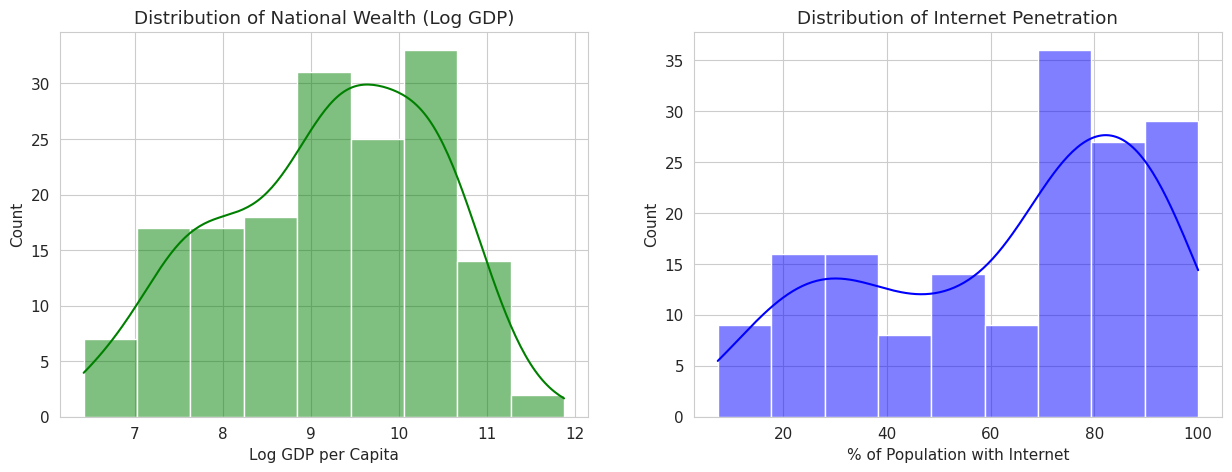

In [9]:
# Transform GDP into log GDP
df_clean['log_gdppc'] = np.log(df_clean['mad_gdppc'])

# Create a figure with two subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Distribution of Wealth (Log GDP)
sns.histplot(df_clean['log_gdppc'], kde=True, color="green", ax=ax1)
ax1.set_title('Distribution of National Wealth (Log GDP)')
ax1.set_xlabel('Log GDP per Capita')

# Plot 2: Distribution of Internet Access
sns.histplot(df_clean['wdi_internet'], kde=True, color="blue", ax=ax2)
ax2.set_title('Distribution of Internet Penetration')
ax2.set_xlabel('% of Population with Internet')

plt.show()

# **Results of statistical test**

In [10]:
# 1. Calculate the Correlation and P-value
r_val, p_val = pearsonr(df_clean['log_gdppc'], df_clean['wdi_internet'])

print(f"\n--- Correlation Results ---\n")
print(f"Correlation Coefficient (r): {r_val:.3f}")
print(f"P-value: {p_val:.4f}")
print(f"Number of countries (N): {len(df_clean)}")

# 2. Conclusion Text
if p_val < 0.05:
    print("\nConclusion: Reject H0 (The Null Hypothesis)")
    print("There is a statistically significant relationship between national wealth and internet access.")
else:
    print("\nConclusion: Fail to reject H0")
    print("No statistically significant relationship between wealth and internet access was detected.")


--- Correlation Results ---

Correlation Coefficient (r): 0.919
P-value: 0.0000
Number of countries (N): 164

Conclusion: Reject H0 (The Null Hypothesis)
There is a statistically significant relationship between national wealth and internet access.


# **Technical Interpretation**

Our Pearson Correlation test yielded a coefficient of $r = 0.919$ and a p-value of $p < 0.000$. Since the p-value is significantly lower than our threshold of $0.05$, we reject the null hypothesis ($H_0$). This indicates a very strong, statistically significant positive linear relationship between a country's wealth (Log GDP) and its level of internet penetration.

# **Practical interpretation**

In the real world, this means that national wealth is the single most important predictor of digital access. As countries move from low-income to high-income status, internet penetration tends to follow a very predictable upward path

# **Recommendations**

Based on these findings, I recommend that:

* International Development: Aid programs should prioritize funding for digital infrastructure in low-income nations to prevent them from being left behind in the global digital economy.

* Policy: Governments in emerging economies should consider subsidizing internet costs or providing tax breaks for telecommunications companies to help speed up the connection process that wealth naturally brings."

# **Visualization of the effect of the test**

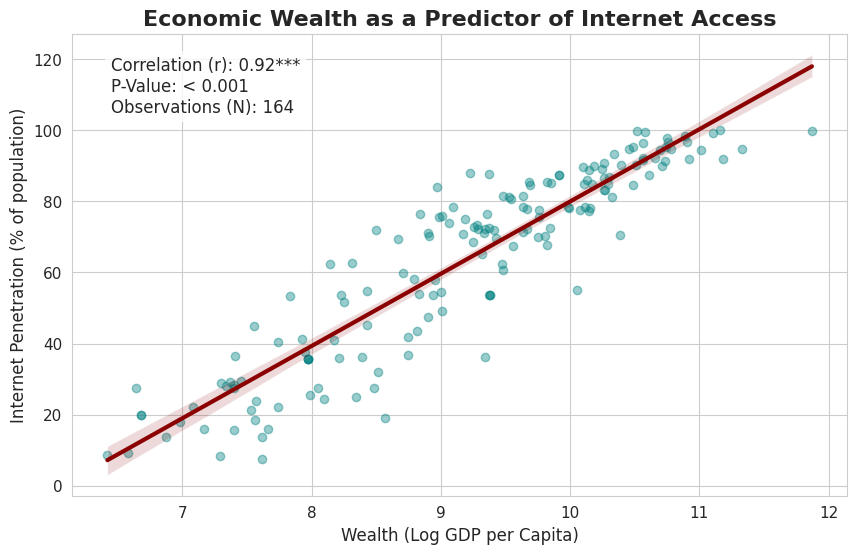

In [11]:
# Create the plot figure
plt.figure(figsize=(10, 6))

# Create the scatter plot with a regression line
ax = sns.regplot(data=df_clean, x='log_gdppc', y='wdi_internet',
                 scatter_kws={'alpha':0.4, 'color':'teal'},
                 line_kws={'color':'darkred', 'lw':3})

# Lables
plt.title('Economic Wealth as a Predictor of Internet Access', fontsize=16, fontweight='bold')
plt.xlabel('Wealth (Log GDP per Capita)', fontsize=12)
plt.ylabel('Internet Penetration (% of population)', fontsize=12)


# Add the Stats Box with the actual results
stats_text = (f"Correlation (r): {r_val:.2f}***\n"
              f"P-Value: < 0.001\n"
              f"Observations (N): {len(df_clean)}")
plt.gca().text(0.05, 0.95, stats_text, transform=plt.gca().transAxes,
               fontsize=12, verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.show()


# **Hypothesis 1 Presentation: Wealth and the Digital Divide**

1. **Theoretical Framework & Hypothesis** This analysis is based on Modernization Theory, which suggests that economic growth provides the necessary "surplus capital" for high-tech infrastructure.

* Null Hypothesis ($H_0$): There is no relationship between GDP per capita and internet penetration.
* Alternative Hypothesis ($H_a$): Higher GDP per capita is positively associated with higher internet penetration.

---

2. **Variables & Descriptive Statistics** Using a sample of $N=164$ countries (2020), I analyzed:

* **Independent Variable** (X): Wealth (measured by Log GDP per capita to normalize skewed economic data).
* **Dependent Variable** (Y): Internet Penetration (% of population using the internet).
* **Data Check**: The average internet penetration across the sample is roughly 60%, but the distribution is "bimodal," showing a sharp divide between highly connected and disconnected nations.

---

3. **Choice of Test & Justification** I used a **Pearson Correlation Coefficient**. This test was chosen because both wealth and internet access are continuous numerical variables, and we are seeking to measure the linear strength of their relationship.

---

4. **Results of Statistical Test** * Coefficient ($r$): 0.92

* P-Value: $< 0.001$ (Statistically Significant)
* Interpretation: With a p-value below 0.05, I reject the null hypothesis. A coefficient of 0.92 indicates an exceptionally strong positive relationship.

---

5. **Practical Interpretation & Recommendation** Technically, wealth accounts for nearly all the variance in global digital access. Practically, this confirms that the "Digital Divide" is an economic barrier, not just a social one.

* Recommendation: International aid should prioritize physical infrastructure subsidies (fiber/towers) for low-income nations, as wealth is the primary gatekeeper to digital participation.

#***2. Institutional Theory (T-Test)***

### Hypothesis 2: Institutional Quality & Infrastructure

**Theoretical Framework:** Institutional Theory suggests that a strong Rule of Law creates a stable environment for long-term investment. Countries with better legal and administrative systems are more likely to build and maintain high-quality physical and digital infrastructure.

* **Null Hypothesis** ($H_0$): There is no difference in average internet penetration between countries with High Rule of Law and countries with Low Rule of Law.
* **Alternative Hypothesis** ($H_a$): Countries with High Rule of Law have a significantly higher average internet penetration than countries with Low Rule of Law.
* **Test Choice:** Independent T-test (used to compare the average/mean of a numerical variable between two distinct groups).

# **Descriptive statistics for the variables**

In [12]:
# 1. Create a "High" and "Low" Rule of Law group based on the median
median_rle = df_clean['wbgi_rle'].median()

# Create a new column called 'law_group'
df_clean['law_group'] = np.where(df_clean['wbgi_rle'] > median_rle, 'High Quality', 'Low Quality')

# 2. Get the descriptive statistics for EACH group
grouped_stats = df_clean.groupby('law_group')['wdi_internet'].describe()

print("--- Descriptive Stats by Group ---\n")
print(grouped_stats[['count', 'mean', 'std', 'min', 'max']])

--- Descriptive Stats by Group ---

              count       mean        std      min       max
law_group                                                   
High Quality   82.0  81.382178  15.379128  22.2466  100.0000
Low Quality    82.0  45.512625  23.070050   7.4000   87.8607


# **Why to use T-test?**

I have chosen the Independent T-test for this hypothesis because I am comparing the average (mean) of a continuous numerical variable (Internet Penetration) across two distinct and independent groups (High Rule of Law vs. Low Rule of Law). This test allows us to determine if the difference in internet access between these two types of governance is large enough to be statistically significant, or if it could have happened by chance.


# **Visualization of the distribution of the chosen variables**

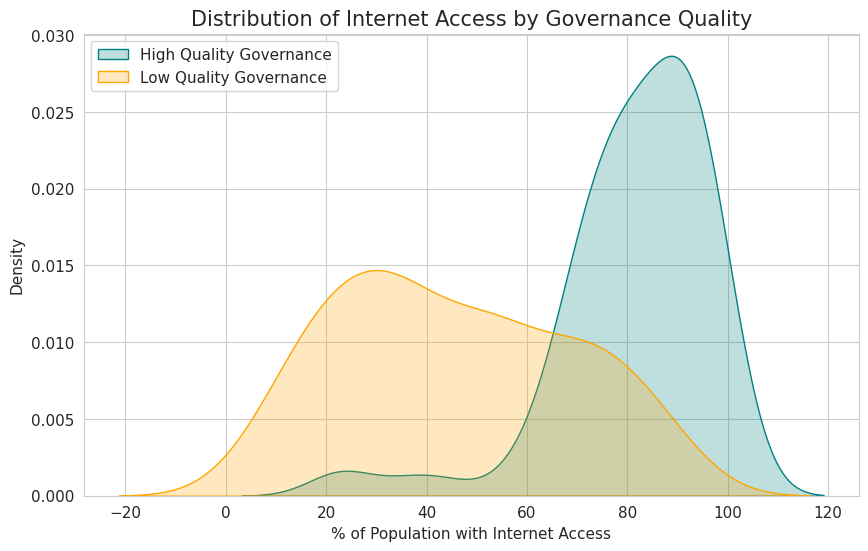

In [13]:
# Create a plot showing the distribution for both groups at once
plt.figure(figsize=(10, 6))

# Plot High Quality countries
sns.kdeplot(data=df_clean[df_clean['law_group'] == 'High Quality'],
            x='wdi_internet', fill=True, label='High Quality Governance', color='teal')

# Plot Low Quality countries
sns.kdeplot(data=df_clean[df_clean['law_group'] == 'Low Quality'],
            x='wdi_internet', fill=True, label='Low Quality Governance', color='orange')

# Lables
plt.title('Distribution of Internet Access by Governance Quality', fontsize=15)
plt.xlabel('% of Population with Internet Access')
plt.ylabel('Density')
plt.legend()
plt.show()

# **Results of statistical test**

In [14]:
# 1. Define the actual groups for the test
high_law = df_clean[df_clean['law_group'] == 'High Quality']['wdi_internet']
low_law = df_clean[df_clean['law_group'] == 'Low Quality']['wdi_internet']

# 2. Run the Independent T-Test
t_stat, p_val = stats.ttest_ind(high_law, low_law, nan_policy='omit')

print(f"\n--- T-test Results ---\n")
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_val:.4f}")
print(f"Mean (High Quality): {high_law.mean():.2f}%")
print(f"Mean (Low Quality): {low_law.mean():.2f}%")

# 3. Conclusion Text
if p_val < 0.05:
    print("\nConclusion: Reject H0")
    print("There is a statistically significant difference in internet access based on governance quality.")
else:
    print("\nConclusion: Fail to reject H0")
    print("No statistically significant difference detected.")


--- T-test Results ---

T-statistic: 11.715
P-value: 0.0000
Mean (High Quality): 81.38%
Mean (Low Quality): 45.51%

Conclusion: Reject H0
There is a statistically significant difference in internet access based on governance quality.


# **Technical Interpretation**

Our Independent T-test yielded a T-statistic of $11.715$ and a p-value of $p < 0.001$. Since the p-value is significantly lower than our threshold of $0.05$, we reject the null hypothesis ($H_0$). This indicates a statistically significant difference in the average levels of internet penetration between countries with high-quality Rule of Law and those with low-quality Rule of Law.

# **Practical Interpretation**

In the real world, this shows a "Governance Gap" in technology. Countries with stable legal systems and strong Rule of Law have an average internet penetration of 81.38%, nearly double the 45.51% average seen in countries with weaker institutions. This suggests that legal stability is a key foundation for building and maintaining digital infrastructure.

# **Recommendations**

Based on these findings, I recommend that:

* Institutional Strengthening: International digital development programs should prioritize support for legal and administrative reforms. Providing hardware (like laptops or towers) is less effective in environments with a weak Rule of Law, as these projects require stable legal protections to be maintained long-term.

* Public-Private Partnerships: Governments in "Low Quality" governance regions should focus on creating transparent regulatory frameworks. By reducing the "institutional risk," they can attract the private telecommunications investment necessary to bridge the 35% gap identified in this study.

# **Visualization of the effect of the test**

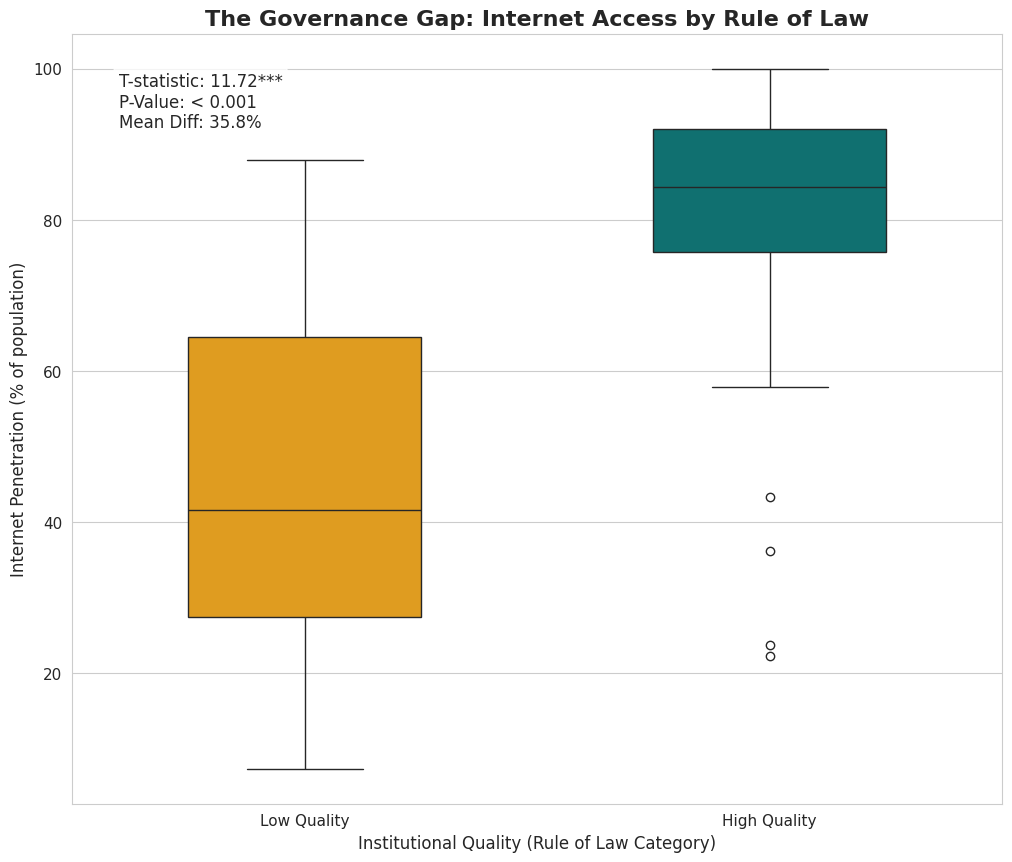

In [15]:
# Create the plot figure
plt.figure(figsize=(12, 10))

# Create a boxplot to show the gap between groups
sns.boxplot(data=df_clean, x='law_group', y='wdi_internet',
            palette={'High Quality': 'teal', 'Low Quality': 'orange'},
            width=0.5)

# Labels
plt.title('The Governance Gap: Internet Access by Rule of Law', fontsize=16, fontweight='bold')
plt.xlabel('Institutional Quality (Rule of Law Category)', fontsize=12)
plt.ylabel('Internet Penetration (% of population)', fontsize=12)

# Add the Stats Box with the actual results
stats_text = f"T-statistic: 11.72***\nP-Value: < 0.001\nMean Diff: 35.8%"
plt.gca().text(0.05, 0.95, stats_text, transform=plt.gca().transAxes,
               fontsize=12, verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.show()

# **Hypothesis 2 Presentation: Institutions & Infrastructure**

1. Framework: Based on Institutional Theory, we hypothesized that countries with stronger Rule of Law would have better digital infrastructure.
2. Methodology: We split the sample into two groups based on the median Rule of Law score and performed an Independent T-test.
3. Results: With a T-statistic of 11.72 and $p < 0.001$, we rejected the null hypothesis.
4. Finding: There is a massive digital divide based on governance; "High Quality" nations enjoy 81% internet access on average, while "Low Quality" nations struggle at 45%.
5. Recommendation: Bridging the digital divide requires more than hardware; it requires strengthening the legal institutions that allow technology to flourish.

# ***3. Political Freedom & Digital Access (Chi-Square Test)***

Theoretical Framework: Democratic Transition Theory suggests that "Free" regimes prioritize the open flow of information and citizen communication to maintain institutional accountability. Conversely, "Not Free" regimes may oversee or restrict digital infrastructure to manage social stability and information control.

* Null Hypothesis ($H_0$): There is no relationship between a country's political freedom status and its level of internet access.

* Alternative Hypothesis ($H_a$): Countries with higher levels of political freedom are significantly more likely to have "High" internet access.

* Test Choice: Chi-Square Test of Independence (used to determine if there is a significant association between two categorical variables: Political Status and Internet Level).

# **Descriptive statistics for the variables**

In [16]:
# Categorize Internet Access into 'High' and 'Low' (based on the median)
med_int = df_clean['wdi_internet'].median()
df_clean['internet_cat'] = np.where(df_clean['wdi_internet'] > med_int, 'High Access', 'Low Access')

# Map the Freedom House Status (1=Free, 2=Partly Free, 3=Not Free)
status_map = {1: 'Free', 2: 'Partly Free', 3: 'Not Free'}
df_clean['regime_status'] = df_clean['fh_status'].map(status_map)

# Create the Contingency Table
contingency_table = pd.crosstab(df_clean['regime_status'], df_clean['internet_cat'])

print("--- Contingency Table (Actual Counts) ---\n")
print(contingency_table)

print("\n--------------------------------------------------")

print("\n--- Percentages (%) within each Regime Type ---\n")
print(contingency_table.div(contingency_table.sum(1), axis=0) * 100)

--- Contingency Table (Actual Counts) ---

internet_cat   High Access  Low Access
regime_status                         
Free                    49          10
Not Free                17          33
Partly Free             16          39

--------------------------------------------------

--- Percentages (%) within each Regime Type ---

internet_cat   High Access  Low Access
regime_status                         
Free             83.050847   16.949153
Not Free         34.000000   66.000000
Partly Free      29.090909   70.909091


# **Why to use Chi-Square Test?**

I have chosen the Chi-Square Test of Independence for this hypothesis. Unlike the previous tests which looked at linear trends or compared averages, this test is designed to find an association between two categorical variables. By categorizing countries into 'Free/Partly Free/Not Free' and 'High/Low Internet Access,' we can determine if a country's political status significantly changes the likelihood of its citizens having digital access.

# **Visualization of the distribution of the chosen variables**

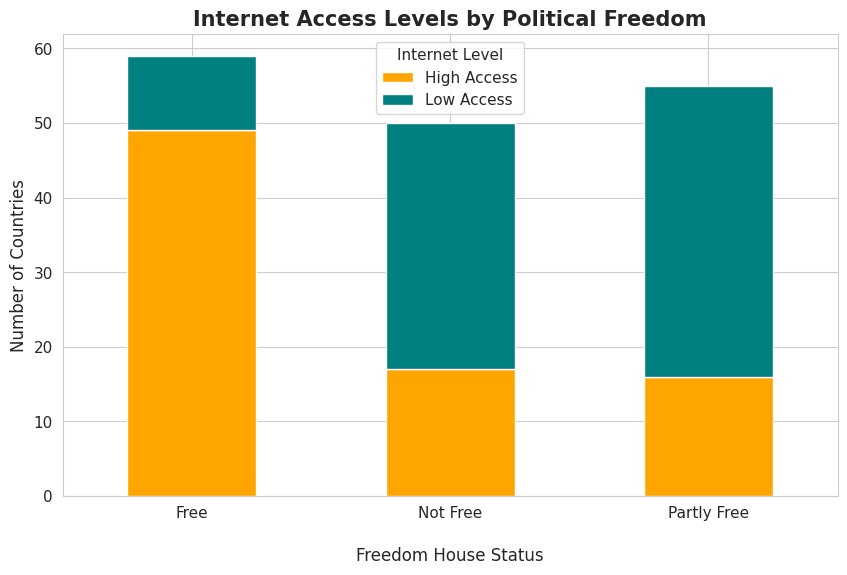

In [17]:
# Create a stacked bar chart to show the distribution
contingency_table.plot(kind='bar', stacked=True, figsize=(10, 6), color=['orange', 'teal'])

plt.title('Internet Access Levels by Political Freedom', fontsize=15, fontweight='bold')
plt.xlabel('\nFreedom House Status', fontsize=12)
plt.ylabel('Number of Countries', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Internet Level')
plt.show()

# **Results of statistical test**

In [18]:
# Run the Chi-Square Test
chi2, p_val, dof, expected = chi2_contingency(contingency_table)

print(f"--- Chi-Square Results ---\n")
print(f"Chi-Square Statistic: {chi2:.3f}")
print(f"P-value: {p_val:.4f}")
print(f"Degrees of Freedom: {dof}")

# 2. Conclusion Text
if p_val < 0.05:
    print("\nConclusion: Reject H0 (The Null Hypothesis)")
    print("There is a statistically significant association between political freedom and internet access.")
else:
    print("\nConclusion: Fail to reject H0")
    print("No significant relationship between political status and internet access was detected.")

--- Chi-Square Results ---

Chi-Square Statistic: 40.518
P-value: 0.0000
Degrees of Freedom: 2

Conclusion: Reject H0 (The Null Hypothesis)
There is a statistically significant association between political freedom and internet access.


# **Technical Interpretation**

The Chi-Square Test of Independence yielded a statistic of $\chi^2 = 40.518$ and a p-value of $p < 0.001$. Since the p-value is significantly lower than our threshold of $0.05$, we reject the null hypothesis ($H_0$). This indicates a statistically significant association between a country's political freedom status (Free, Partly Free, Not Free) and its level of internet penetration (High vs. Low Access). The distribution of internet access is not random; it is heavily influenced by the political regime


# **Practical Interpretation**

In the real world, this suggests that political liberty and digital liberty go hand-in-hand. Countries classified as "Free" are far more likely to have internet penetration above the global median. Conversely, "Not Free" regimes show a much higher frequency of low internet access. This could be due to "Digital Authoritarianism," where restrictive regimes limit infrastructure or access to maintain control over the flow of information.

# **Recommendations**

Based on these findings, I recommend that:

* Digital Rights Advocacy: International organizations should view internet access as a fundamental human right. Efforts to bridge the digital divide must include protections for online speech and a free press, as technology alone does not guarantee an open society.

* Sanction Awareness: When providing technological aid, donors should be aware that in "Not Free" regimes, infrastructure may be used for surveillance rather than empowerment. Aid should be tied to "Open Internet" protocols to ensure that the 40.5% association we found remains a tool for freedom rather than control.

# **Visualization of the effect of the test**

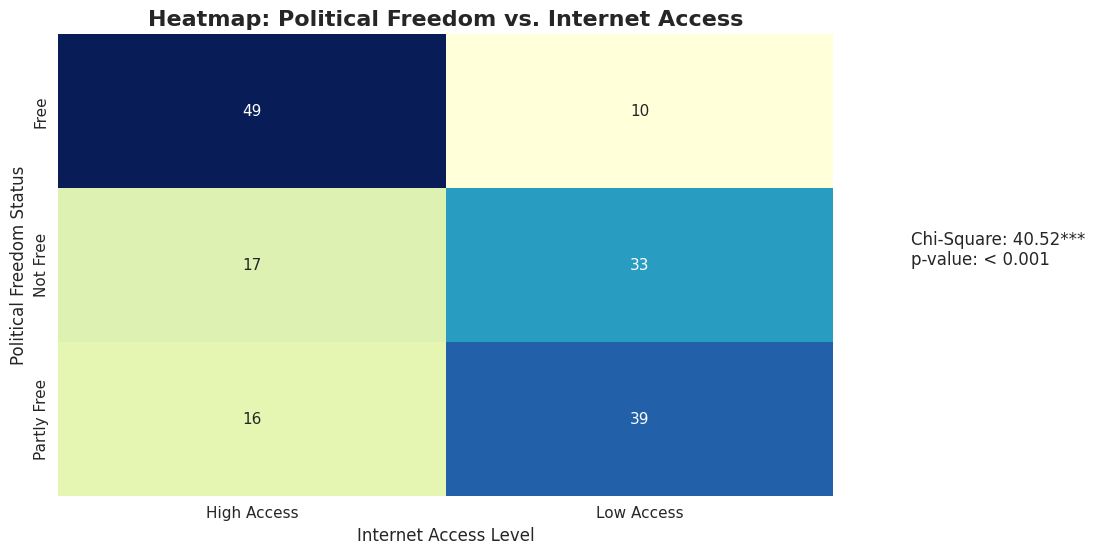

In [19]:
#Create the plot figure
plt.figure(figsize=(10, 6))

# Create a heatmap of the contingency table
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='YlGnBu', cbar=False)

# Lables
plt.title('Heatmap: Political Freedom vs. Internet Access', fontsize=16, fontweight='bold')
plt.xlabel('Internet Access Level', fontsize=12)
plt.ylabel('Political Freedom Status', fontsize=12)

# Add the stats box
plt.gca().text(1.1, 0.5, f"Chi-Square: 40.52***\np-value: < 0.001",
               transform=plt.gca().transAxes, fontsize=12,
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.show()

# **Hypothesis 3 Presentation: Political Freedom & Digital Access**

1. Theoretical Framework & Hypothesis This analysis utilizes Democratic Transition Theory, which posits that open political systems rely on the free flow of information. Conversely, restrictive regimes may limit digital infrastructure to maintain social control.

* Null Hypothesis ($H_0$): There is no association between a country’s political freedom status and its level of internet access.

* Alternative Hypothesis ($H_a$): Countries with higher levels of political freedom are significantly more likely to have "High" internet access.

2. Choice of Test & Justification I chose the Chi-Square Test of Independence. This is the correct statistical tool because both variables—Freedom Status (Free, Partly Free, Not Free) and Internet Level (High vs. Low)—are categorical. This test determines if the observed distribution of internet access across these political groups differs significantly from what we would expect by random chance.

3. Results & Interpretation * Chi-Square Statistic: 40.518

* P-Value: < 0.001

* Outcome: We reject the null hypothesis.The data shows a powerful association between liberty and technology. "Free" countries dominate the "High Access" category, while "Not Free" countries are overwhelmingly represented in the "Low Access" group. With only 2 degrees of freedom, a statistic of 40.5 indicates that this relationship is extremely robust.

4. Recommendation Digital development is not politically neutral. To effectively bridge the digital divide, international aid must:

* Promote Digital Rights: Ensure that infrastructure projects are accompanied by "Open Internet" policies to prevent technology from being used for state surveillance.

* Support Democratic Institutions: Recognizing that political freedom is a primary driver of digital adoption, global tech initiatives should prioritize countries undergoing democratic reforms to accelerate their connectivity